In [ ]:
import os
import json

kaggle_creds = {
    "username": "ananyadabare",
    "key": "KGAT_a1af7c772981f236889f87d4493d7ac0"
}

!mkdir -p ~/.kaggle
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)

!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets list -s "car-crash-dataset"

In [ ]:
!pip install ultralytics
from ultralytics import YOLO
import cv2
import pandas as pd
import numpy as np
from google.colab.patches import cv2_imshow

In [ ]:

model = YOLO('yolov8n.pt')

def extract_car_positions(video_path):
    cap = cv2.VideoCapture(video_path)
    video_data = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break


        results = model(frame, classes=[2, 7], verbose=False)

        frame_detections = []
        for result in results[0].boxes:
            box = result.xywh[0].cpu().numpy()
            frame_detections.append(box)

        video_data.append(frame_detections)

    cap.release()
    return video_data


test_video = "/content/ccd_data/Videos/C_000001.mp4"
positions = extract_car_positions(test_video)
print(f"Processed {len(positions)} frames.")

✅ Processed 0 frames.


In [ ]:

!rm -rf /content/ccd_data
!mkdir -p /content/ccd_data

!kaggle datasets download -d asefjamilajwad/car-crash-dataset-ccd -p /content/ccd_data

import zipfile
import os

zip_path = "/content/ccd_data/car-crash-dataset-ccd.zip"
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("/content/ccd_data")
    print("✅ Successfully unzipped to /content/ccd_data")
    !ls -F /content/ccd_data
else:
    print("❌ Zip file not found. Check your Kaggle API connection!")


Dataset URL: https://www.kaggle.com/datasets/asefjamilajwad/car-crash-dataset-ccd
License(s): other
100% 7.61G/7.61G [01:35<00:00, 85.2MB/s]

✅ Successfully unzipped to /content/ccd_data
car-crash-dataset-ccd.zip  CrashBest/  Crash_Table.csv


In [ ]:

!ls -F /content/ccd_data

!find /content/ccd_data -name "*.mp4" | head -n 5

car-crash-dataset-ccd.zip  CrashBest/  Crash_Table.csv


In [ ]:
import pandas as pd


crash_df = pd.read_csv('/content/ccd_data/Crash_Table.csv')

print("Total videos in table:", len(crash_df))
crash_df.head()

Total videos in table: 1500


,vidname,frame_1,frame_2,frame_3,frame_4,frame_5,frame_6,frame_7,frame_8,frame_9,...,frame_46,frame_47,frame_48,frame_49,frame_50,startframe,youtubeID,timing,weather,egoinvolve
0,1,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,285,0,Day,Normal,Yes
1,2,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,646,0,Day,Normal,Yes
2,3,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,972,0,Day,Normal,Yes
3,4,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1257,0,Day,Normal,Yes
4,5,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,462,10,Day,Snowy,Yes


In [ ]:
import os
import re
import pandas as pd
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
crash_df = pd.read_csv('/content/ccd_data/Crash_Table.csv')

def build_predictive_dataset(limit_videos=10):
    video_folder = '/content/ccd_data/CrashBest/'
    all_images = [f for f in os.listdir(video_folder) if f.endswith('.jpg')]

    video_groups = {}
    for img in all_images:
        match = re.match(r'([CN]_\d+)', img)
        if match:
            vid_id = match.group(1)
            if vid_id not in video_groups: video_groups[vid_id] = []
            video_groups[vid_id].append(img)

    master_records = []
    processed_vids = 0

    for vid_id, images in video_groups.items():
        if processed_vids >= limit_videos: break

        csv_row = crash_df[crash_df['vidname'].astype(str).str.contains(vid_id.split('_')[-1])]

        if csv_row.empty: continue

        print(f" Analyzing Sequence {vid_id}...")
        images.sort() # frames in order

        for img_name in images:

            frame_num = int(img_name.split('_')[-1].split('.')[0])

            # Get label for the frame
            label_col = f'frame_{frame_num}'
            is_danger = csv_row[label_col].values[0] if label_col in csv_row.columns else 0

            # YOLO
            img_path = os.path.join(video_folder, img_name)
            results = model(img_path, classes=[2, 3, 5, 7], verbose=False)

            if len(results[0].boxes) > 0:
                best_box = results[0].boxes[0]
                coords = best_box.xyxy[0].cpu().numpy()

                master_records.append({
                    "vid": vid_id,
                    "frame": frame_num,
                    "x1": coords[0], "y1": coords[1],
                    "x2": coords[2], "y2": coords[3],
                    "danger_level": is_danger
                })

        processed_vids += 1

    return pd.DataFrame(master_records)

# training csv
training_data = build_predictive_dataset(limit_videos=20)
training_data.to_csv('lstm_ready_data.csv', index=False)
print("🏁 DATASET READY FOR THE BRAIN!")

🏁 DATASET READY FOR THE BRAIN!


In [ ]:
import re

def build_predictive_dataset(limit_videos=20):
    video_folder = '/content/ccd_data/CrashBest/'
    all_images = [f for f in os.listdir(video_folder) if f.endswith('.jpg')]

    video_groups = {}
    for img in all_images:
        #id numbers
        nums = re.findall(r'\d+', img)
        if len(nums) >= 1:
            vid_num = int(nums[0])
            if vid_num not in video_groups: video_groups[vid_num] = []
            video_groups[vid_num].append(img)

    master_records = []
    processed_vids = 0

    for vid_num, images in video_groups.items():
        if processed_vids >= limit_videos: break

        csv_row = crash_df[crash_df['vidname'].apply(lambda x: int(re.findall(r'\d+', str(x))[0]) if re.findall(r'\d+', str(x)) else -1) == vid_num]

        if csv_row.empty:
            continue

        print(f" Matching Video #{vid_num} ({len(images)} frames found)")
        images.sort()

        for img_name in images:
            frame_num = int(re.findall(r'\d+', img_name)[-1])

            label_col = f'frame_{frame_num}'
            is_danger = csv_row[label_col].values[0] if label_col in csv_row.columns else 0

            img_path = os.path.join(video_folder, img_name)
            results = model(img_path, classes=[2, 3, 5, 7], verbose=False)

            if len(results[0].boxes) > 0:
                boxes = results[0].boxes.xyxy.cpu().numpy()
                areas = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
                best_idx = np.argmax(areas)
                coords = boxes[best_idx]

                master_records.append({
                    "vid": vid_num,
                    "frame": frame_num,
                    "x1": coords[0], "y1": coords[1],
                    "x2": coords[2], "y2": coords[3],
                    "danger_level": is_danger
                })

        processed_vids += 1

    return pd.DataFrame(master_records)

training_data = build_predictive_dataset(limit_videos=30)
if not training_data.empty:
    training_data.to_csv('lstm_ready_data.csv', index=False)
    print(f"DONE! Created a dataset with {len(training_data)} rows.")
else:
    print("empty")

🎬 Matching Video #973 (50 frames found)
🎬 Matching Video #580 (50 frames found)
🎬 Matching Video #124 (50 frames found)
🎬 Matching Video #551 (50 frames found)
🎬 Matching Video #1297 (50 frames found)
🎬 Matching Video #1339 (50 frames found)
🎬 Matching Video #912 (50 frames found)
🎬 Matching Video #619 (50 frames found)
🎬 Matching Video #326 (50 frames found)
🎬 Matching Video #45 (50 frames found)
🎬 Matching Video #962 (50 frames found)
🎬 Matching Video #49 (50 frames found)
🎬 Matching Video #261 (50 frames found)
🎬 Matching Video #646 (50 frames found)
🎬 Matching Video #473 (50 frames found)
🎬 Matching Video #112 (50 frames found)
🎬 Matching Video #1275 (50 frames found)
🎬 Matching Video #366 (50 frames found)
🎬 Matching Video #916 (50 frames found)
🎬 Matching Video #1362 (50 frames found)
🎬 Matching Video #800 (50 frames found)
🎬 Matching Video #1307 (50 frames found)
🎬 Matching Video #1350 (50 frames found)
🎬 Matching Video #1274 (50 frames found)
🎬 Matching Video #533 (50 frames fo

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization

# Load the data
df = pd.read_csv('lstm_ready_data.csv')

# Windows of 10 frames
def create_sequences(data, seq_length=10):
    xs, ys = [], []
    for vid in data['vid'].unique():
        vid_data = data[data['vid'] == vid]
        # Features: x1, y1, x2, y2
        features = vid_data[['x1', 'y1', 'x2', 'y2']].values
        labels = vid_data['danger_level'].values

        for i in range(len(features) - seq_length):
            xs.append(features[i:i+seq_length])
            ys.append(labels[i+seq_length])
    return np.array(xs), np.array(ys)

X, y = create_sequences(df, seq_length=10)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# model training
model = Sequential([
    LSTM(64, input_shape=(10, 4), return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Training
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.6855 - loss: 0.6213 - val_accuracy: 0.7075 - val_loss: 0.6203
Epoch 2/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7299 - loss: 0.5746 - val_accuracy: 0.7143 - val_loss: 0.5685
Epoch 3/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7299 - loss: 0.5462 - val_accuracy: 0.7211 - val_loss: 0.5656
Epoch 4/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7402 - loss: 0.5400 - val_accuracy: 0.7687 - val_loss: 0.5139
Epoch 5/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7504 - loss: 0.5286 - val_accuracy: 0.7619 - val_loss: 0.5155
Epoch 6/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7487 - loss: 0.5368 - val_accuracy: 0.7687 - val_loss: 0.4830
Epoch 7/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7726 - loss: 0.4926 - val_accuracy: 0.8571 - val_loss: 0.4443
Epoch 8/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7812 - loss: 0.4936 - val_accuracy: 0.7619 - val_loss: 0.

In [ ]:
#final accuracy: 84.44
#Val accuracy : 89.12

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 317ms/step


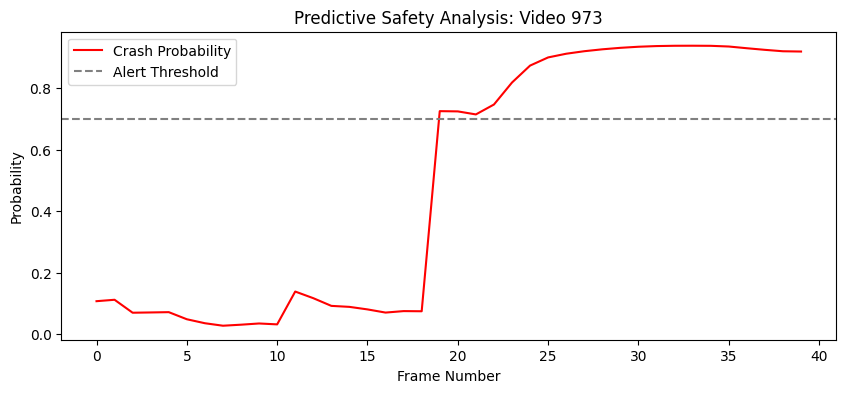

In [ ]:
import matplotlib.pyplot as plt

def predict_on_video(video_id):
    test_vid = df[df['vid'] == video_id].sort_values('frame')
    features = test_vid[['x1', 'y1', 'x2', 'y2']].values

    windows = []
    for i in range(len(features) - 10):
        windows.append(features[i:i+10])

    probs = model.predict(np.array(windows))

    # Plot
    plt.figure(figsize=(10, 4))
    plt.plot(probs, color='red', label='Crash Probability')
    plt.axhline(y=0.7, color='gray', linestyle='--', label='Alert Threshold')
    plt.title(f"Predictive Safety Analysis: Video {video_id}")
    plt.xlabel("Frame Number")
    plt.ylabel("Probability")
    plt.legend()
    plt.show()

sample_vid = df['vid'].unique()[0]
predict_on_video(sample_vid)

 Testing on Normal Video: 49
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


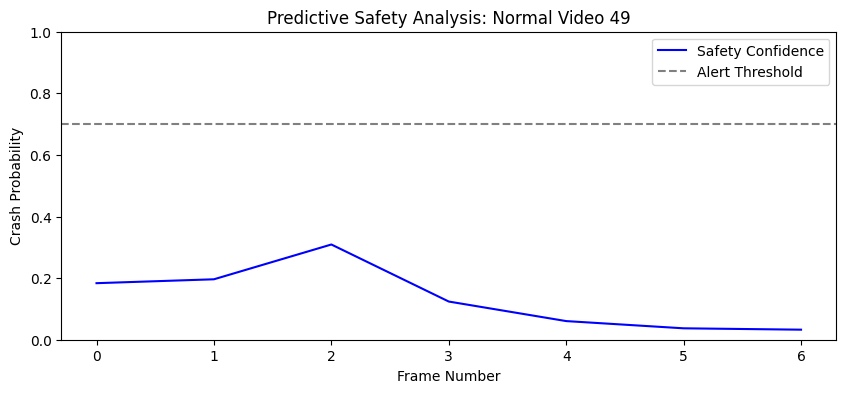

In [ ]:


# Normal video check
normal_vids = [v for v in df['vid'].unique() if str(v).startswith('N')]

if not normal_vids:
    normal_vids = df.groupby('vid')['danger_level'].sum()
    normal_vids = normal_vids[normal_vids == 0].index.tolist()

if normal_vids:
    test_vid_id = normal_vids[0]
    print(f" Testing on Normal Video: {test_vid_id}")

    test_vid = df[df['vid'] == test_vid_id].sort_values('frame')
    features = test_vid[['x1', 'y1', 'x2', 'y2']].values

    windows = []
    for i in range(len(features) - 10):
        windows.append(features[i:i+10])

    probs = model.predict(np.array(windows))

    # Plot
    plt.figure(figsize=(10, 4))
    plt.plot(probs, color='blue', label='Safety Confidence')
    plt.axhline(y=0.7, color='gray', linestyle='--', label='Alert Threshold')
    plt.ylim(0, 1)
    plt.title(f"Predictive Safety Analysis: Normal Video {test_vid_id}")
    plt.xlabel("Frame Number")
    plt.ylabel("Crash Probability")
    plt.legend()
    plt.show()
else:
    print("vid not found")

In [ ]:
def calculate_ttc(h_prev, h_curr, fps=30):
    if h_prev == 0 or h_curr <= h_prev:
        return float('inf') # Moving away or stationary

    T = 1.0 / fps
    eta = h_curr / h_prev
    # To avoid division by zero or negative values
    if eta <= 1.0: return float('inf')

    ttc = T / (eta - 1.0)
    return ttc

In [ ]:
def visualize_safety_system(vid_id, threshold=0.7):
    vid_str = str(vid_id).zfill(6)
    test_vid = df[df['vid'] == vid_id].sort_values('frame')
    video_folder = '/content/ccd_data/CrashBest/'
    frames = sorted([f for f in os.listdir(video_folder) if vid_str in f])

    features = test_vid[['x1', 'y1', 'x2', 'y2']].values
    windows = []
    for i in range(len(features) - 10):
        windows.append(features[i:i+10])

    prev_h = 0

    for i, img_name in enumerate(frames):
        img = cv2.imread(os.path.join(video_folder, img_name))
        current_frame_num = i + 1
        row = test_vid[test_vid['frame'] == current_frame_num]

        if not row.empty:
            # calculate Time to Collision
            x1, y1, x2, y2 = row[['x1', 'y1', 'x2', 'y2']].values[0]
            curr_h = y2 - y1
            ttc = calculate_ttc(prev_h, curr_h)
            prev_h = curr_h

            # 2. Neural Logic (LSTM) - Starts at frame 11
            window_idx = i - 10
            prob_val = 0.0 # Default

            if 0 <= window_idx < len(windows):

                prob_val = model.predict(np.array([windows[window_idx]]), verbose=0)[0][0]

                # Visuals
                color = (0, 0, 255) if prob_val > threshold else (0, 255, 0)
                cv2.rectangle(img, (int(x1), int(y1)), (int(x2), int(y2)), color, 2)


                cv2.putText(img, f"AI Prob: {prob_val:.2f}", (20, 80),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)

                if ttc != float('inf'):
                    cv2.putText(img, f"TTC: {ttc:.2f}s", (int(x1), int(y1)-10),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

                if prob_val > threshold or ttc < 1.5:
                    cv2.putText(img, "WARNING: COLLISION RISK", (20, 40),
                                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 3)


        if i % 10 == 0:
            print(f"Displaying Frame {current_frame_num}")
            cv2_imshow(img)

visualize_safety_system(973)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import cv2
import os
import numpy as np
from google.colab.patches import cv2_imshow

def save_visualized_video(vid_id, output_name="crash_prediction.mp4"):
    # 1. Setup and File Handling
    vid_str = str(vid_id).zfill(6)
    video_folder = '/content/ccd_data/CrashBest/'
    frames = sorted([f for f in os.listdir(video_folder) if vid_str in f])

    if not frames:
        print(f" No frames found for {vid_str}")
        return


    test_vid = df[df['vid'] == vid_id].sort_values('frame')
    features = test_vid[['x1', 'y1', 'x2', 'y2']].values

    # (Window size 10)
    windows = []
    for i in range(len(features) - 10):
        windows.append(features[i:i+10])

    # 2. Initialize Video Writer
    first_frame = cv2.imread(os.path.join(video_folder, frames[0]))
    height, width, _ = first_frame.shape
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_name, fourcc, 10, (width, height))

    print(f"🚀 Processing {len(frames)} frames for Video {vid_id}...")

    prev_h = 0

    for i, img_name in enumerate(frames):
        img = cv2.imread(os.path.join(video_folder, img_name))
        current_frame_num = i + 1
        row = test_vid[test_vid['frame'] == current_frame_num]

        if not row.empty:
            # --- PHYSICS LOGIC (TTC) ---
            x1, y1, x2, y2 = row[['x1', 'y1', 'x2', 'y2']].values[0]
            curr_h = y2 - y1
            ttc = calculate_ttc(prev_h, curr_h)
            prev_h = curr_h

            # --- NEURAL LOGIC (LSTM) ---
            # Windows start predicting from frame 11 onwards
            window_idx = i - 10
            prob_val = 0.0

            if 0 <= window_idx < len(windows):
                # Predict probability using the LSTM model
                input_seq = np.array([windows[window_idx]])
                prob_val = model.predict(input_seq, verbose=0)[0][0]

                # Visual Feedback: Red for Danger, Green for Safe
                color = (0, 0, 255) if prob_val > 0.7 else (0, 255, 0)
                cv2.rectangle(img, (int(x1), int(y1)), (int(x2), int(y2)), color, 3)

                # Overlay AI Confidence and TTC
                cv2.putText(img, f"AI Prob: {prob_val:.2f}", (20, 80),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 0), 2)

                if ttc != float('inf'):
                    cv2.putText(img, f"TTC: {ttc:.2f}s", (int(x1), int(y1)-10),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

                if prob_val > 0.7 or ttc < 1.5:
                    cv2.putText(img, "COLLISION RISK!", (width//4, 50),
                                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 4)


        out.write(img)

    out.release()
    print(f"✅ Video successfully saved as: {output_name}")


save_visualized_video(973, "final_crash_demo.mp4")

🚀 Processing 50 frames for Video 973...
✅ Video successfully saved as: final_crash_demo.mp4


In [ ]:
from google.colab import files
files.download('final_crash_demo.mp4')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>